In [153]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [154]:
df = pd.read_csv("reviews.csv")

In [155]:
df.head()



,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [156]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [157]:
df.isnull().sum()


App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

In [158]:
df = df.dropna(subset  = ["Translated_Review"])

In [159]:

df = df.drop_duplicates()
df.isnull().sum()


App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

In [160]:
df["Translated_Review"].str.lower()

0        i like eat delicious food. that's i'm cooking ...
1          this help eating healthy exercise regular basis
3               works great especially going grocery store
4                                             best idea us
5                                                 best way
                               ...                        
64222    most ads older many agents ..not much owner po...
64223    if photos posted portal load, fit purpose. i'm...
64226    dumb app, i wanted post property rent give opt...
64227    i property business got link sms happy perform...
64230    useless app, i searched flats kondapur, hydera...
Name: Translated_Review, Length: 29692, dtype: object

In [161]:
df["App"].nunique()

865

In [162]:
df["App"].value_counts().head(10)

App
Facebook                          130
Episode - Choose Your Story       124
Angry Birds Classic               107
Family Locator - GPS Tracker      105
Google Photos                     101
8fit Workouts & Meal Planner      100
Calorie Counter - Macros          100
Calorie Counter - MyFitnessPal     99
ColorNote Notepad Notes            99
Adobe Acrobat Reader               98
Name: count, dtype: int64

In [163]:


app_df = df[df["App"]  == "Google Photos"]    

Sentiment
Positive    76
Negative    24
Neutral      1
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x1d61beed2b0>,
 [Text(-0.7838423967562251, 0.7717454872219575, 'Positive'),
  Text(0.7594621889362801, -0.7957494477384914, 'Negative'),
  Text(1.0994679109009151, -0.03420983629276139, 'Neutral')])

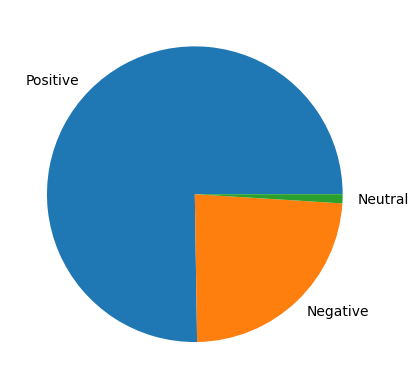

In [189]:
a = app_df["Sentiment"].value_counts()
print(a)
plt.pie(a, labels = a.index)

In [165]:
print(f"Most reviews are {a.idxmax()}")

Most reviews are Positive


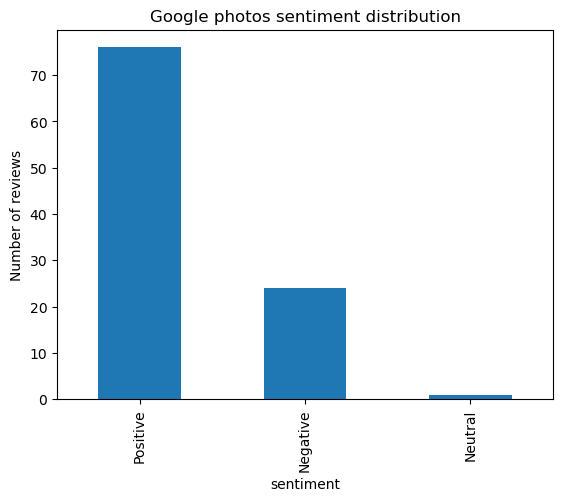

In [166]:
app_df["Sentiment"].value_counts().plot(kind = "bar")
plt.title("Google photos sentiment distribution")
plt.xlabel("sentiment")
plt.ylabel("Number of reviews")
plt.show()

In [167]:
avg = app_df["Sentiment_Polarity"].mean()
avg

np.float64(0.1870211671841937)

In [168]:
if avg> 0:
    print("Users generally have a positive perception of the app.")

elif avg < 0:
    print("Users generally have a negative perception of the app.")

else:
    print("Users have neutral perception of the app.")

Users generally have a positive perception of the app.


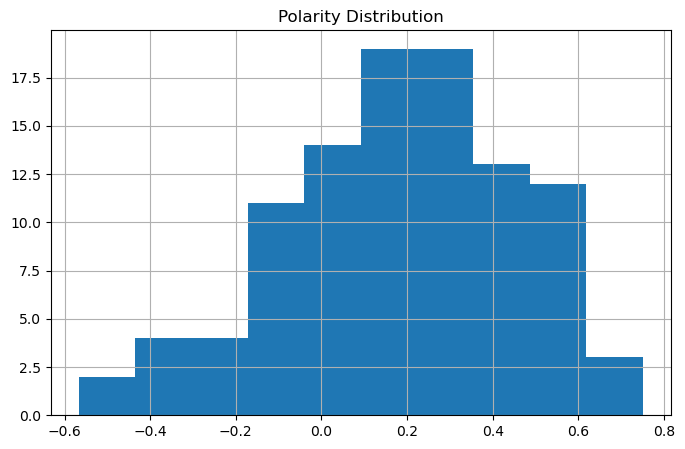

In [169]:
app_df["Sentiment_Polarity"].hist(figsize = (8,5))
plt.title("Polarity Distribution")
plt.show()

In [170]:
app_df["Sentiment_Subjectivity"].mean()

np.float64(0.5093049769655145)

In [171]:
# moderately strong positive sentiment

In [172]:
negative_reviews = app_df[app_df["Sentiment"] == "Negative"]


In [173]:
total_reviews = len(app_df)
negative_percentage = (len(negative_reviews)/ total_reviews)* 100
print(negative_percentage)

23.762376237623762


In [174]:
if negative_percentage > 30:
    print("High number of negative reviews detected.")

else:
    print("Negative reviews are under control.")

Negative reviews are under control.


In [175]:
negative_reviews["Translated_Review"].head(20)

56420    Sharing needs granular control. Why way preven...
56423    I'm hard time Photos I'm getting really pissed...
56430    I go back photos find back nice albums I've al...
56432    I lost hundreds downloaded photos app. Wheneve...
56436    What f wrong new update. It worsen photo viewi...
56440    Forced Android phone. When I send photo someon...
56444    Its difficult image phone's gallery. Hence, Im...
56445    Extremely sluggish Huawei P20 Pro. Swiping ima...
56446    Overall quite good, current flow swiping pictu...
56447    I love saves memories well make movie feature ...
56473    Garbage ,just like ever single Google product ...
56552    Why add damn FOLDERS? IF I backup images phone...
56556    There editing options shared pics. It's quite ...
56567    Constant notifications. Very annoying app. It ...
56568    Like I'm full screen notification update whene...
56583    You get "memories " make selection photo trans...
56587    Since updating Samsung 7 active, photos keeps .

In [176]:
positive_review = app_df[app_df["Sentiment"] == "Positive"]
positive_review["Translated_Review"].head(20)

56410    Out photo I've used I enjoy features most. The...
56411    I installed "Google Photos" IOS devices Samsun...
56412    Best option I've seen photo organization Andro...
56413    Google Photos automatically converted photos o...
56414    Enjoying much. Would give 5 stars way create s...
56415    Its great alot issues. You able organize order...
56416    back I know love. No crashing, easy backup syn...
56417    This great photo gallery app. You back photos ...
56418    This must top 5 anyone Smartphone. Takes away ...
56419    I love intuitive Google sends personalized mov...
56421    Never knew capabilites this. Discovered love i...
56422    Right, I went swimming I got back data warning...
56424    I love camera features. I would like see Googl...
56425    When Photos become pushy manipulative? It's al...
56426    It consumes much data, takes much time load pi...
56428    I never want share photos device. I never want...
56429    I never disappointed life. I backed phone, I t.

In [177]:
pip install wordcloud


Note: you may need to restart the kernel to use updated packages.


In [178]:
from wordcloud import WordCloud

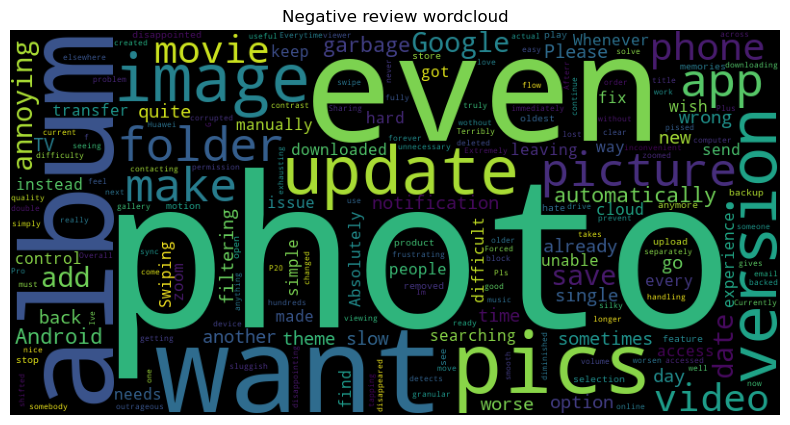

In [179]:
text = " ".join(negative_reviews["Translated_Review"])
wordcloud = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize = (10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative review wordcloud")
plt.show()
                

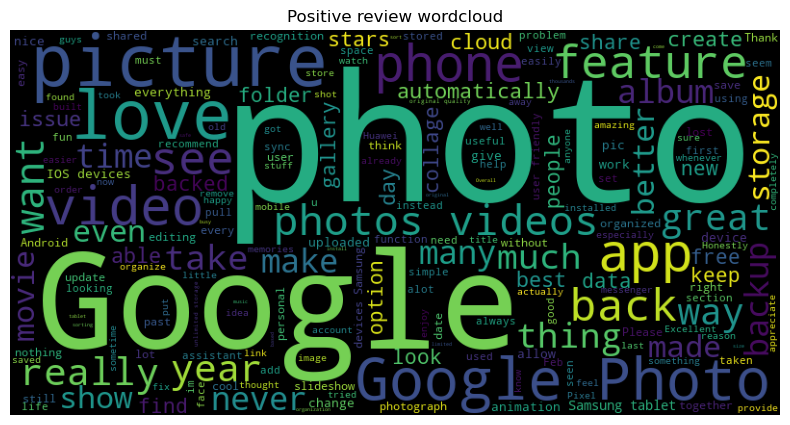

In [180]:
text = " ".join(positive_review["Translated_Review"])
wordcloud = WordCloud(width=800, height=400).generate(text)
plt.figure(figsize = (10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive review wordcloud")

plt.show()
                

In [181]:
app_df.shape


(101, 5)

In [182]:
app_df.head()



,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
56410,Google Photos,Out photo I've used I enjoy features most. The...,Positive,0.231006,0.408442
56411,Google Photos,"I installed ""Google Photos"" IOS devices Samsun...",Positive,0.125000,0.300000
56412,Google Photos,Best option I've seen photo organization Andro...,Positive,0.339286,0.592857
56413,Google Photos,Google Photos automatically converted photos o...,Positive,0.308500,0.632333
56414,Google Photos,Enjoying much. Would give 5 stars way create s...,Positive,0.112245,0.605102


In [183]:
print(app_df.columns)

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


In [184]:
app_df.to_csv("clean.csv",
              index = False)

In [185]:
import seaborn as sns

C:\Users\vasan\AppData\Local\Temp\ipykernel_17456\295751456.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app_df["Sentiment_Score"] = app_df[


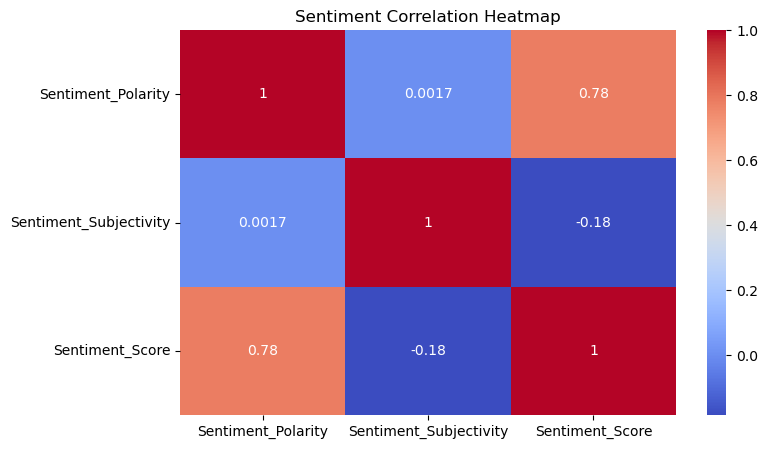

In [186]:
sentiment_map = {
    "Positive": 1,
    "Neutral": 0,
    "Negative": -1
}
app_df["Sentiment_Score"] = app_df[
    "Sentiment"
].map(sentiment_map)

numeric_df = app_df[
    [
        "Sentiment_Polarity",
        "Sentiment_Subjectivity",
        "Sentiment_Score"
    ]
]

corr = numeric_df.corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Sentiment Correlation Heatmap")
plt.show()